## RNN, LSTM — 시계열 예측

**데이터:** `Dataset/electricity.csv` (지역 난방 시계열)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| Device:', device)


In [ ]:
path = '/content/drive/MyDrive/7일차'
DATA_PATH = os.path.join(path,'Dataset/electricity.csv')

df = pd.read_csv(DATA_PATH)
df.head()


##### 1) 데이터 확인

* `supplyT` : 공급 온도
* `returnT` : 환수 온도
* `volume` / `flow` : 유량
* `energy` : 열에너지 사용량
* `Frederikshavn Temperature` : 외기 온도
* `OT` : 예측 대상 (Outlet Temperature)


In [ ]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(12, 3))
plt.plot(df['date'], df['OT'], linewidth=0.8)
plt.title('OT (Outlet Temperature) over time')
plt.xlabel('date')
plt.tight_layout()
plt.show()

print('rows:', len(df), '| columns:', list(df.columns))


##### 2) Train / Test 분할 & 전처리

* 시계열이므로 **앞 80% train, 뒤 20% test** (shuffle 없음)
* `Lag`개 과거 시점 → `Horizon`개 미래 `OT` 예측


In [ ]:
Lag = 14       # 입력 시퀀스 길이 (look-back)
Horizon = 7    # 예측 시퀀스 길이
targetSeries = 'OT'

idx = int(df.shape[0] * 0.8)
df_train = df[:idx].dropna().reset_index(drop=True)
df_test = df[idx:].dropna().reset_index(drop=True)

In [ ]:
# 테스트 시작부에 train 마지막 Lag개 붙여 연속성 유지
df_test = pd.concat([df_train.iloc[-Lag:], df_test]).reset_index(drop=True)

In [ ]:
df_test

In [ ]:
features_to_scale = df.columns.drop(['date'])

In [ ]:
scaler = StandardScaler()

In [ ]:
df_train[features_to_scale] 

In [ ]:
df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

In [ ]:
df_train[features_to_scale] 

* `Lag` 만큼 input을 만들어서 이후 `Horizon` 구간의 `OT`를 예측

👉🏻 한 시점 feature만 쓰는 MLP와 달리, **여러 시점의 추세**를 RNN/LSTM이 학습


In [ ]:
feature_cols = df.columns.drop(['date'])

In [ ]:
def create_dataset(df, Lag=1, Horizon=1, targetSeries=None, feature_cols=None):
    dataX, dataY, dataDate = [], [], []
    for i in tqdm(range(0, df.shape[0] + 1 - Lag - Horizon)):
        dataX.append(df[feature_cols].iloc[i:(i + Lag)].to_numpy())
        dataY.append(df[targetSeries].iloc[i + Lag: i + Lag + Horizon].to_numpy())
        dataDate.append(df['date'].iloc[i + Lag: i + Lag + Horizon].tolist())
    return np.array(dataX), np.array(dataY), np.array(dataDate)


In [ ]:
trainX, trainY, _ = create_dataset(df_train, Lag, Horizon, targetSeries, feature_cols)
testX, testY, testDate = create_dataset(df_test, Lag, Horizon, targetSeries, feature_cols)


In [ ]:
trainX.shape, trainY.shape

In [ ]:
trainX[0]

In [ ]:
trainY[0]

In [ ]:
df_train[features_to_scale][:14]

In [ ]:
df_train['OT'][14:21]

In [ ]:
## 최종적으로 Validation Dataset까지 구축
vidx = int(0.9 * trainX.shape[0])
validX, validY = trainX[vidx:], trainY[vidx:]
trainX, trainY = trainX[:vidx], trainY[:vidx]

trainY = np.expand_dims(trainY, axis=-1)
validY = np.expand_dims(validY, axis=-1)
testY = np.expand_dims(testY, axis=-1)

print('Training:  ', trainX.shape, trainY.shape)
print('Validation:', validX.shape, validY.shape)
print('Test:      ', testX.shape, testY.shape)


In [ ]:
## Dataloader를 위한 Dataset 구축

class TSData(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [ ]:
train_dataset = TSData(trainX, trainY)
valid_dataset = TSData(validX, validY)
test_dataset = TSData(testX, testY)

In [ ]:
train_dl = DataLoader(TSData(trainX, trainY), batch_size=16, shuffle=False)
valid_dl = DataLoader(TSData(validX, validY), batch_size=16, shuffle=False)
test_dl = DataLoader(TSData(testX, testY), batch_size=16, shuffle=False)

input_size = trainX.shape[2]

In [ ]:
for x, y in train_dl:
  break

In [ ]:
x.shape, y.shape

In [ ]:
## 모델 학습 함수 정의

def train_model(model, train_dl, valid_dl, model_name, num_epochs=20, lr=1e-4):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5, min_lr=1e-10,
    )
    
    history = {'train': [], 'valid': []}
    best_score = None

    for epoch in range(1, num_epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        train_loss /= len(train_dl.dataset)

        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_dl:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                valid_loss += criterion(out, yb).item() * xb.size(0)
        valid_loss /= len(valid_dl.dataset)

        history['train'].append(train_loss)
        history['valid'].append(valid_loss)
        print(f'[{model_name}] Epoch {epoch:02d} train={train_loss:.6f} valid={valid_loss:.6f}')

        if best_score is None or valid_loss < best_score:
            best_score = valid_loss
            torch.save(model.state_dict(), f'{model_name}.pth')

        scheduler.step(valid_loss)
        
    model.load_state_dict(torch.load(f'{model_name}.pth', map_location=device))
    return model, history, criterion


In [ ]:
@torch.no_grad()
def predict_loader(model, loader):
    preds, targets = [], []
    model.eval()
    for xb, yb in loader:
        xb = xb.to(device)
        out = model(xb).cpu().numpy()
        preds.append(out)
        targets.append(yb.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(targets, axis=0)


def inverse_target(pred, target, scaler, feature_cols, targetSeries):
    n_samples = pred.shape[0]
    pred_flat = pred.reshape(-1, 1)
    target_flat = target.reshape(-1, 1)
    tidx = list(feature_cols).index(targetSeries)
    nfeat = len(feature_cols)

    pred_full = np.zeros((pred_flat.shape[0], nfeat))
    target_full = np.zeros((target_flat.shape[0], nfeat))
    pred_full[:, tidx] = pred_flat.squeeze()
    target_full[:, tidx] = target_flat.squeeze()

    pred_inv = scaler.inverse_transform(pred_full)[:, tidx].reshape(n_samples, Horizon)
    target_inv = scaler.inverse_transform(target_full)[:, tidx].reshape(n_samples, Horizon)
    return pred_inv, target_inv


##### 3) Model 구축

* RNN


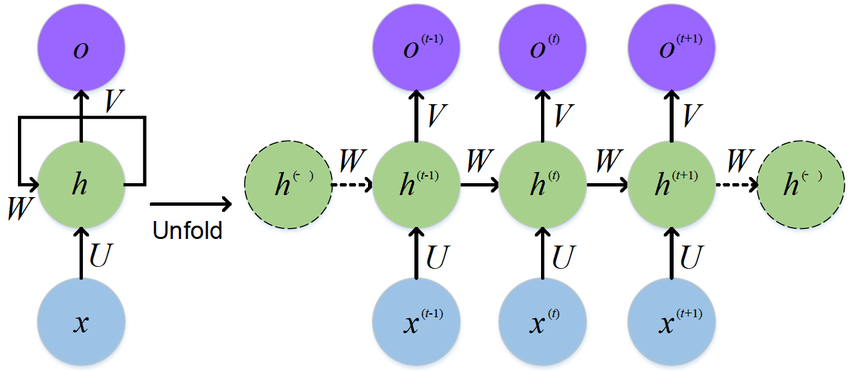

In [ ]:
input_size

In [ ]:
rnn_layer = nn.RNN(
    input_size,
    hidden_size=50, # feature dimension
    num_layers=1, # RNN layer 개수
    batch_first=True # (Batch, Sequence, Feature) 면 True 
)

In [ ]:
out = rnn_layer(x)

In [ ]:
len(out)

In [ ]:
out[0].shape # (Batch, Input sequence length, hidden size)

In [ ]:
out[1].shape #(num_layers, sequence length, hidden size)

In [ ]:
out[1][0,0]== out[0][0,-1]

In [ ]:
class RNNForecast(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=2, output_length=Horizon):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_length)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(2)

rnn_model = RNNForecast(input_size=input_size, hidden_size=50, num_layers=2, output_length=Horizon)
print(rnn_model)

In [ ]:
input_size = trainX.shape[2]

In [ ]:
rnn_model, rnn_hist, criterion = train_model(rnn_model, train_dl, valid_dl, 'RNN', num_epochs=20)

rnn_pred, rnn_true = predict_loader(rnn_model, test_dl)
rnn_pred_inv, rnn_true_inv = inverse_target(
    rnn_pred.squeeze(-1), rnn_true.squeeze(-1), scaler, feature_cols, targetSeries,
)
print('RNN test MSE:', criterion(
    torch.tensor(rnn_pred_inv), torch.tensor(rnn_true_inv)
).item())


In [ ]:
plt.figure(figsize=(12, 4))
idx = random.randint(0, len(testDate) - 1)
plt.plot(testDate[idx], rnn_true_inv[idx], 'g-o', label='Real')
plt.plot(testDate[idx], rnn_pred_inv[idx], 'r-o', label='Pred')
plt.title('RNN forecast sample')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


* LSTM


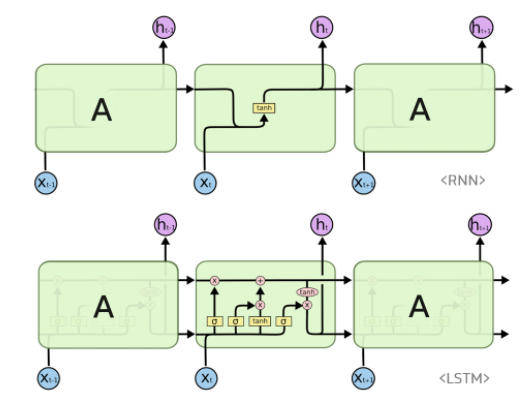

In [ ]:
lstm_layer = nn.LSTM(
    input_size,
    hidden_size=50,
    num_layers=1,
    batch_first=True
)

In [ ]:
out = lstm_layer(x)

In [ ]:
len(out)

In [ ]:
out[0].shape

In [ ]:
out[1].shape

In [ ]:
len(out[1])

In [ ]:
out[1][0].shape, out[1][1].shape # (hidden, cell_state)

In [ ]:
class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size=50, num_layers=3, output_length=Horizon):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_length)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(2)

lstm_model = LSTMForecast(input_size=input_size, hidden_size=50, num_layers=3, output_length=Horizon)
print(lstm_model)


In [ ]:
lstm_model, lstm_hist, criterion = train_model(lstm_model, train_dl, valid_dl, 'LSTM', num_epochs=20)

lstm_pred, lstm_true = predict_loader(lstm_model, test_dl)
lstm_pred_inv, lstm_true_inv = inverse_target(
    lstm_pred.squeeze(-1), lstm_true.squeeze(-1), scaler, feature_cols, targetSeries,
)
print('LSTM test MSE:', criterion(
    torch.tensor(lstm_pred_inv), torch.tensor(lstm_true_inv)
).item())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, hist, name in zip(axes, [rnn_hist, lstm_hist], ['RNN', 'LSTM']):
    ax.plot(hist['train'], label='train')
    ax.plot(hist['valid'], label='valid')
    ax.set_title(f'{name} loss')
    ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
idx = random.randint(0, len(testDate) - 1)
plt.plot(testDate[idx], lstm_true_inv[idx], 'g-o', label='Real')
plt.plot(testDate[idx], lstm_pred_inv[idx], 'r-o', label='Pred')
plt.title('LSTM forecast sample')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
